In [30]:
# standardard pre-processing of all sequenced cells with wnn integration
library(Seurat)
library(Signac)
library(dplyr)
library(ggplot2)

In [31]:
library(ensembldb)
library(AnnotationHub)
ah <- AnnotationHub(localHub=TRUE)
query(ah, "EnsDb")

Using 'localHub=TRUE'
  If offline, please also see BiocManager vignette section on offline use



AnnotationHub with 1 record
# snapshotDate(): 2022-04-21
# names(): AH73861
# $dataprovider: Ensembl
# $species: Danio rerio
# $rdataclass: EnsDb
# $rdatadateadded: 2019-05-02
# $title: Ensembl 97 EnsDb for Danio rerio
# $description: Gene and protein annotations for Danio rerio based on Ensemb...
# $taxonomyid: 7955
# $genome: GRCz11
# $sourcetype: ensembl
# $sourceurl: http://www.ensembl.org
# $sourcesize: NA
# $tags: c("97", "AHEnsDbs", "Annotation", "EnsDb", "Ensembl", "Gene",
#   "Protein", "Transcript") 
# retrieve record with 'object[["AH73861"]]' 

In [32]:
query(ah, "EnsDb")
qr <- query(ah, c("EnsDb", "rerio", "97"))
EnsDb.Drerio.v97 <- qr[[1]]

AnnotationHub with 1 record
# snapshotDate(): 2022-04-21
# names(): AH73861
# $dataprovider: Ensembl
# $species: Danio rerio
# $rdataclass: EnsDb
# $rdatadateadded: 2019-05-02
# $title: Ensembl 97 EnsDb for Danio rerio
# $description: Gene and protein annotations for Danio rerio based on Ensemb...
# $taxonomyid: 7955
# $genome: GRCz11
# $sourcetype: ensembl
# $sourceurl: http://www.ensembl.org
# $sourcesize: NA
# $tags: c("97", "AHEnsDbs", "Annotation", "EnsDb", "Ensembl", "Gene",
#   "Protein", "Transcript") 
# retrieve record with 'object[["AH73861"]]' 

loading from cache



In [33]:
library(hdf5r)
inputdata <- Read10X_h5("./vsx1/outs/filtered_feature_bc_matrix.h5")
rna_counts <- inputdata$`Gene Expression`
atac_counts <- inputdata$'Peaks'


Attaching package: 'hdf5r'


The following object is masked from 'package:GenomicRanges':

    values


The following object is masked from 'package:S4Vectors':

    values


Genome matrix has multiple modalities, returning a list of matrices for this genome



In [34]:
vsx1 <- CreateSeuratObject(counts = rna_counts)
vsx1[["percent.mt"]] <- PercentageFeatureSet(vsx1, pattern = "^mt-")

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


In [35]:
grange.counts <- StringToGRanges(rownames(atac_counts), sep = c(":", "-"))
grange.use <- seqnames(grange.counts) %in% standardChromosomes(grange.counts)
atac_counts <- atac_counts[as.vector(grange.use), ]
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Drerio.v97)
seqlevelsStyle(annotations) <- 'UCSC'
genome(annotations) <- "GRCz11"
frag.file <- "/home/wangmei/NGS/10x_ARC/spinal_vsx1/vsx1/outs/atac_fragments.tsv.gz"
chrom_assay <- CreateChromatinAssay(
   counts = atac_counts,
   sep = c(":", "-"),
   genome = 'GRCz11',
   fragments = frag.file,
   min.cells = 10,
   annotation = annotations
 )
vsx1[["ATAC"]] <- chrom_assay

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


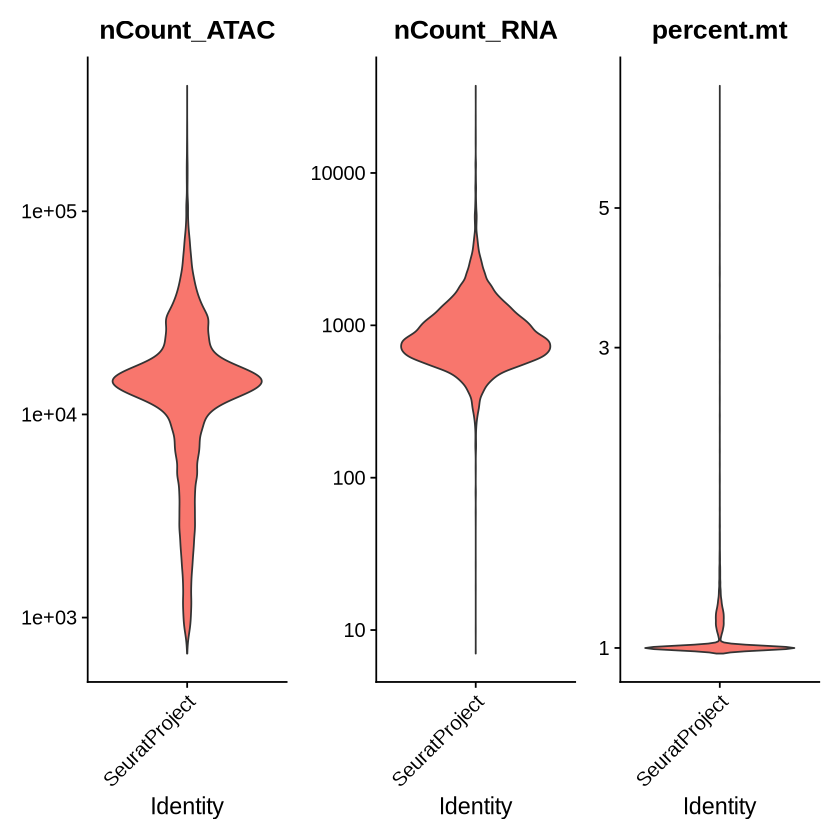

In [36]:
VlnPlot(vsx1, features = c("nCount_ATAC", "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend()

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


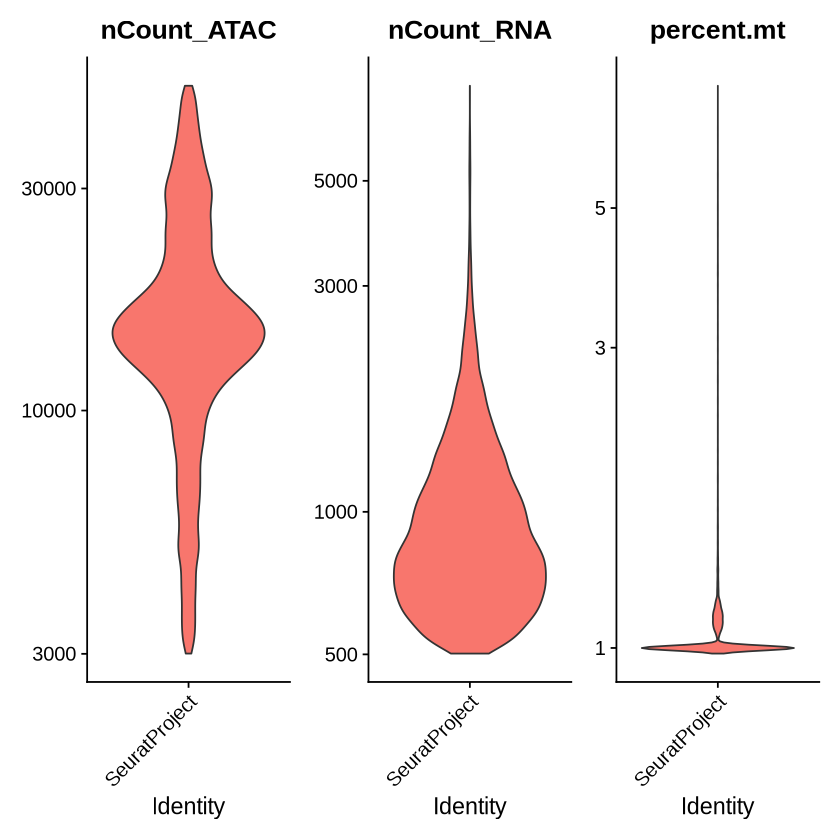

In [37]:
vsx1 <- subset(
  x = vsx1,
  subset = nCount_ATAC < 5e4 &
    nCount_ATAC > 3e3 &
    nCount_RNA < 8000 &
    nCount_RNA > 500
)
VlnPlot(vsx1, features = c("nCount_ATAC", "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend()

An object of class Seurat 
336652 features across 11636 samples within 2 assays 
Active assay: RNA (32520 features, 0 variable features)
 1 layer present: counts
 1 other assay present: ATAC

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


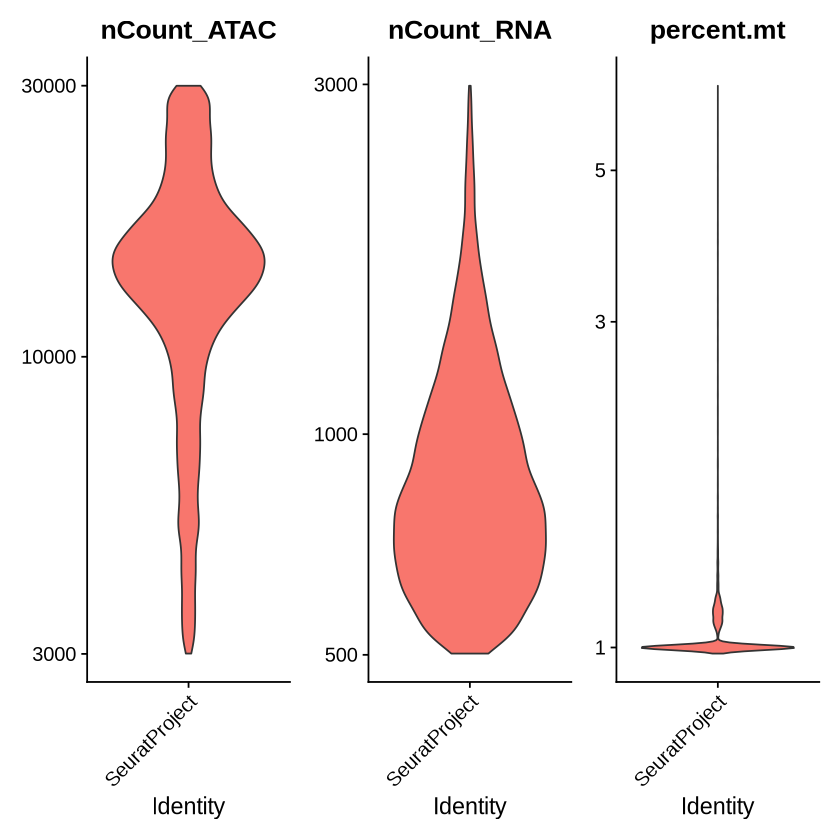

In [38]:
vsx1 <- subset(
  x = vsx1,
  subset = nCount_ATAC < 3e4 &
    nCount_ATAC > 3e3 &
    nCount_RNA < 3000 &
    nCount_RNA > 500
)
vsx1
VlnPlot(vsx1, features = c("nCount_ATAC", "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend()

In [ ]:
DefaultAssay(vsx1) <- "RNA"
vsx1 <- SCTransform(vsx1, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims = 1:50, reduction.name = 'umap.rna', reduction.key = 'rnaUMAP_')
DefaultAssay(vsx1) <- "ATAC"
vsx1 <- RunTFIDF(vsx1)
vsx1 <- FindTopFeatures(vsx1, min.cutoff = 'q0')
vsx1 <- RunSVD(vsx1)
vsx1 <- RunUMAP(vsx1, reduction = 'lsi', dims = 2:50, reduction.name = "umap.atac", reduction.key = "atacUMAP_")
vsx1 <- FindMultiModalNeighbors(vsx1, reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:50))
vsx1 <- RunUMAP(vsx1, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
vsx1 <- FindClusters(vsx1, graph.name = "wsnn", algorithm = 3, verbose = FALSE)

In [40]:
saveRDS(vsx1, file = "vsx1_allcell_wnn.rds")

## replication of Figure S3B

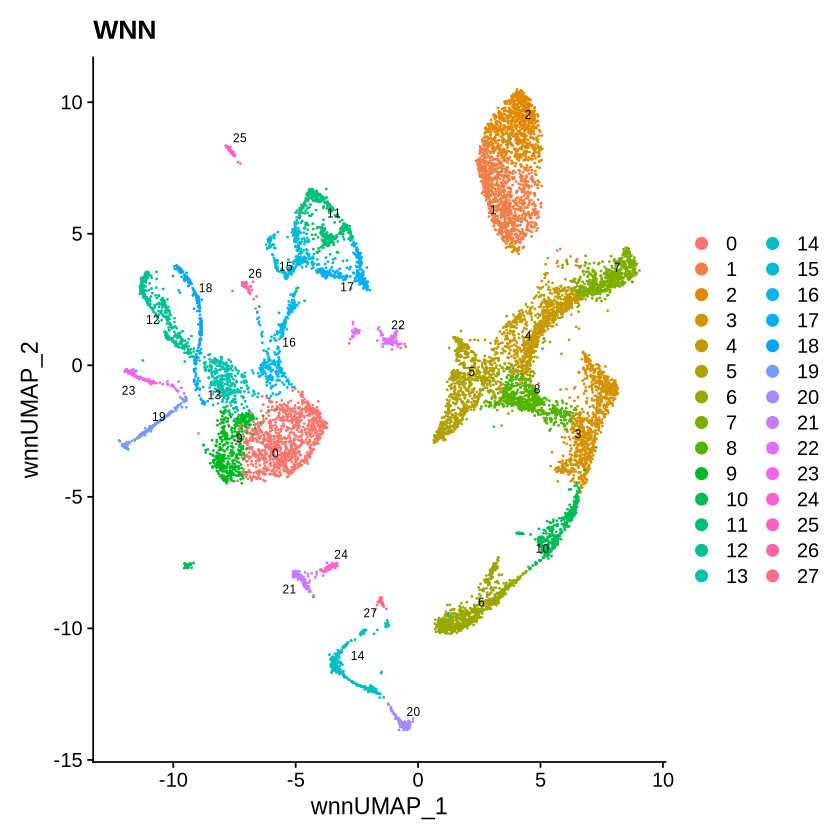

In [41]:
## replication of Figure S3B
DimPlot(vsx1, reduction = "wnn.umap",  label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")

In [69]:
pdf("figure3b.pdf")
DimPlot(vsx1, reduction = "wnn.umap",  label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
dev.off()

pdf 
  2

## check expression of markers of v2a-v2b lineages, replication of Figure S3C

Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"Could not find vsx1 in the default search locations, found in 'SCT' assay instead"
Warning message:
"Could not find tal1 in the default search locations, found in 'SCT' assay instead"
Warning message:
"Could not find vsx2 in the default search locations, found in 'SCT' assay instead"
Warning message:
"Could not find foxn4 in the default search locations, found in 'SCT' assay instead"


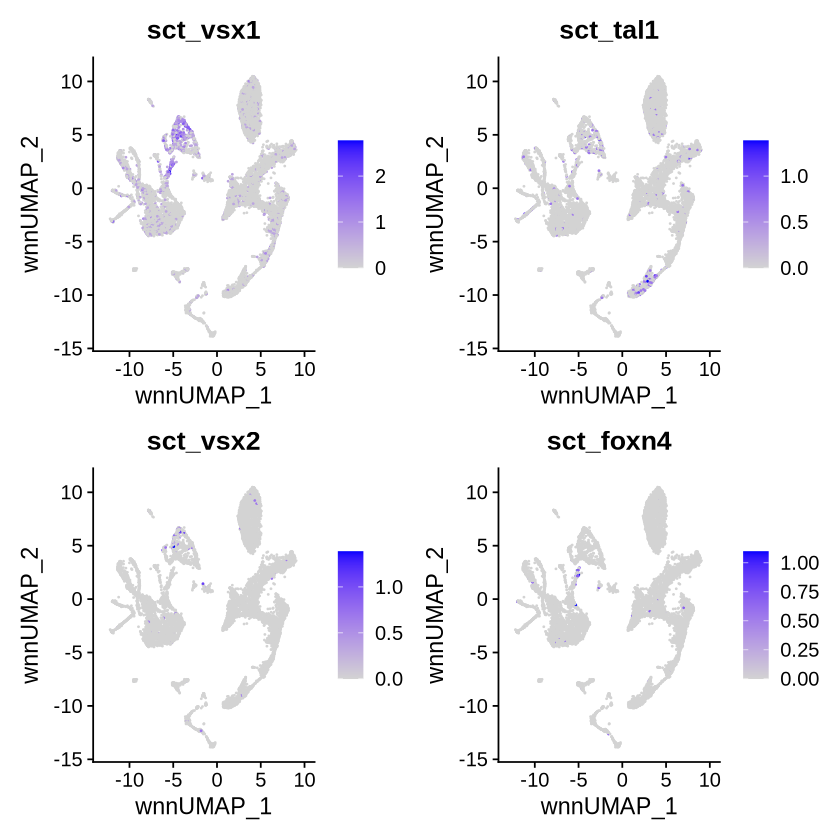

In [42]:
# check expression of v2a-v2b marker genes, replication of Figure S4C
FeaturePlot(vsx1, features = c("vsx1", "tal1", "vsx2", "foxn4"), reduction = 'wnn.umap')

# reanalyze v2a-v2b lineages

In [43]:
#subset and reanalyze v2a-v2b, which highly express vsx1, foxn4, tal1 or vsx2
v2av2b <- subset(vsx1, idents = c("11", "15", "16", "17"))

In [44]:
DefaultAssay(v2av2b) <- "RNA"
v2av2b <- SCTransform(v2av2b, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims = 1:30, reduction.name = 'umap.rna', reduction.key = 'rnaUMAP_')
DefaultAssay(v2av2b) <- "ATAC"
v2av2b <- RunTFIDF(v2av2b)
v2av2b <- FindTopFeatures(v2av2b, min.cutoff = 'q0')
v2av2b <- RunSVD(v2av2b)

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = co

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in glm.nb(formula = as.formula(new_formula), data = data):
"alternation limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limi

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

15:38:47 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:38:47 Read 1249 rows and found 30 numeric columns

15:38:47 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:38:47 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:38:47 Writing NN index file to temp file /tmp/RtmplFSTnd/file48b09c692888

15:38:47 Searching Annoy index using 1 thread, search_k = 3000

15:38:48 Annoy recall = 100%

15:38:49 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:38:52 Initializing from normalized Laplacian + n

In [45]:
v2av2b <- RunUMAP(v2av2b, reduction = 'lsi', dims = 2:30, n.neighbors = 40L, min.dist = 0.4, reduction.name = "umap.atac", reduction.key = "atacUMAP_")
v2av2b <- FindMultiModalNeighbors(v2av2b, reduction.list = list("pca", "lsi"), dims.list = list(1:30, 2:30))
v2av2b <- RunUMAP(v2av2b, n.neighbors = 40L, min.dist = 0.4, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")

15:39:34 UMAP embedding parameters a = 0.7669 b = 1.223

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:39:34 Read 1249 rows and found 29 numeric columns

15:39:34 Using Annoy for neighbor search, n_neighbors = 40

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:39:34 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:39:34 Writing NN index file to temp file /tmp/RtmplFSTnd/file48b0920cedc66

15:39:34 Searching Annoy index using 1 thread, search_k = 4000

15:39:34 Annoy recall = 100%

15:39:36 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 40

15:39:38 Initializing from normalized Laplacian + 

In [46]:
v2av2b <- FindClusters(v2av2b, resolution = 0.6, graph.name = "wsnn", algorithm = 3, verbose = FALSE)

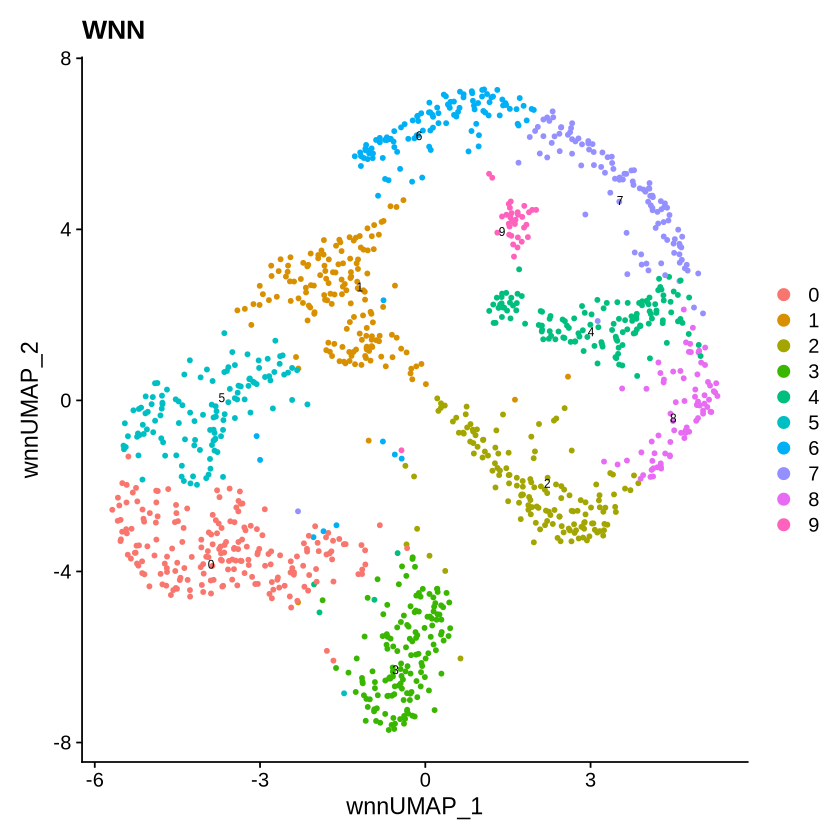

In [47]:
# visualization
DimPlot(v2av2b, reduction = "wnn.umap",  label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")

## replication of Figure S3E

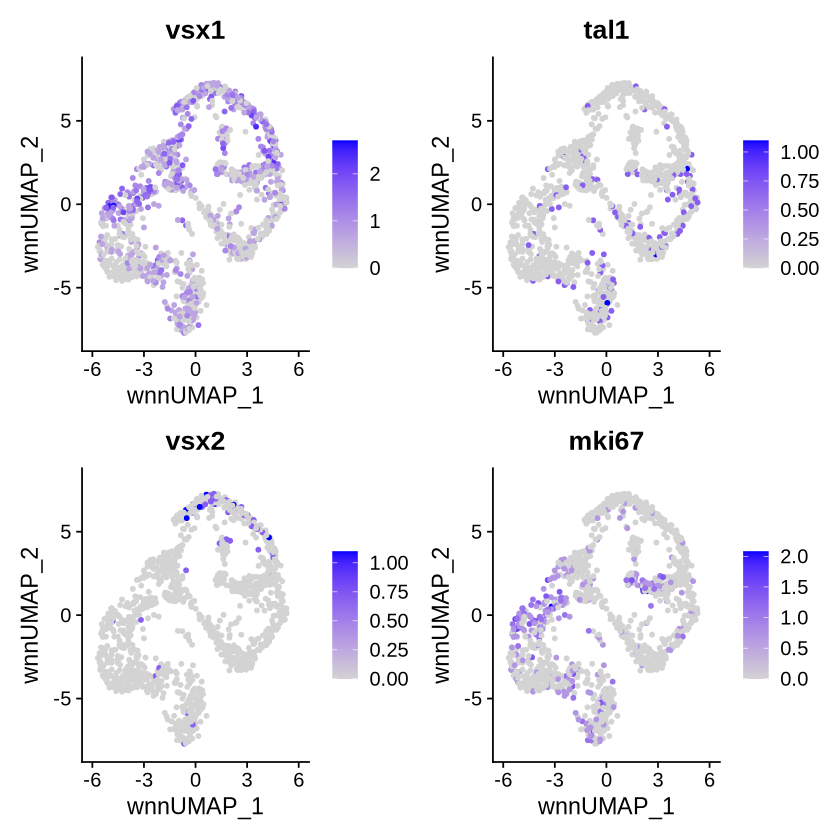

In [48]:
## check expression of marker genes, replication of Figure S3E
DefaultAssay(v2av2b) <- "SCT"
FeaturePlot(v2av2b, features = c("vsx1", "tal1", "vsx2",  "mki67"),  reduction = 'wnn.umap')

## cell type annotation

### replication of Figure S3D

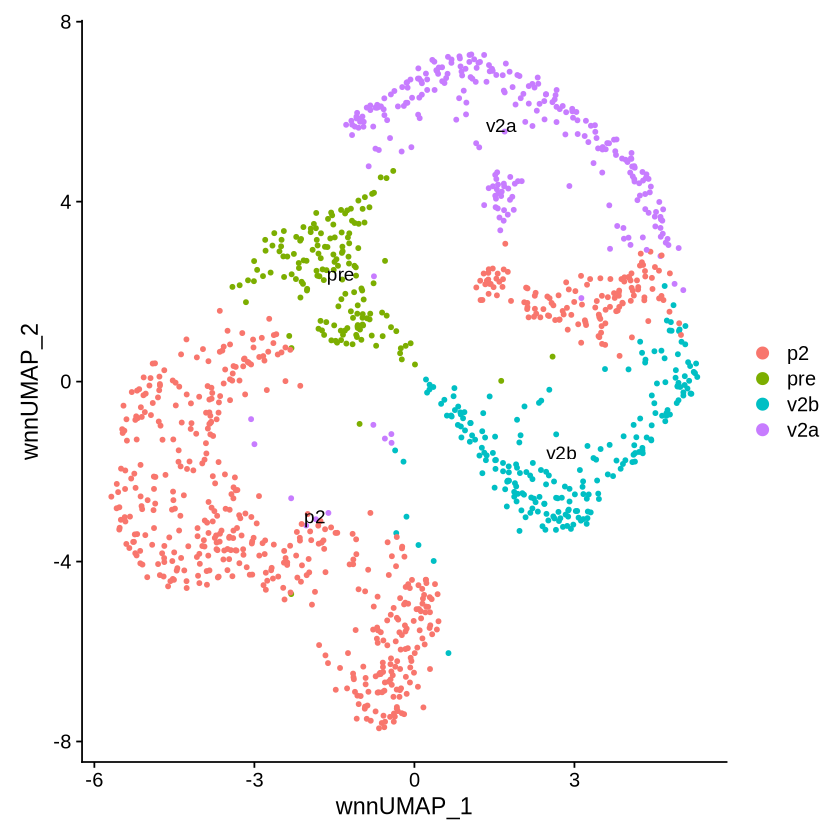

In [49]:
#rename
new.cluster.ids <- c("p2", "pre", "v2b", "p2", "p2", "p2", "v2a", "v2a", "v2b", "v2a")
names(new.cluster.ids) <- levels(v2av2b)
v2av2b <- RenameIdents(v2av2b, new.cluster.ids)
# replication of Figure S3D
DimPlot(v2av2b, reduction = "wnn.umap", label=T)

In [1]:
saveRDS(v2av2b, file = "v2av2b_wnn_annotate.rds")

# analyze 5.8 kb upstream of tal1, replication of Figure 2G

In [2]:
library(ensembldb)
seqlevelsStyle(v2av2b$ATAC@annotation) <- "Ensembl"
DefaultAssay(v2av2b) <- "ATAC"

Loading required package: BiocGenerics




Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loading required package: GenomicFeatures



## check DNA accessiblity in tal1 promoter

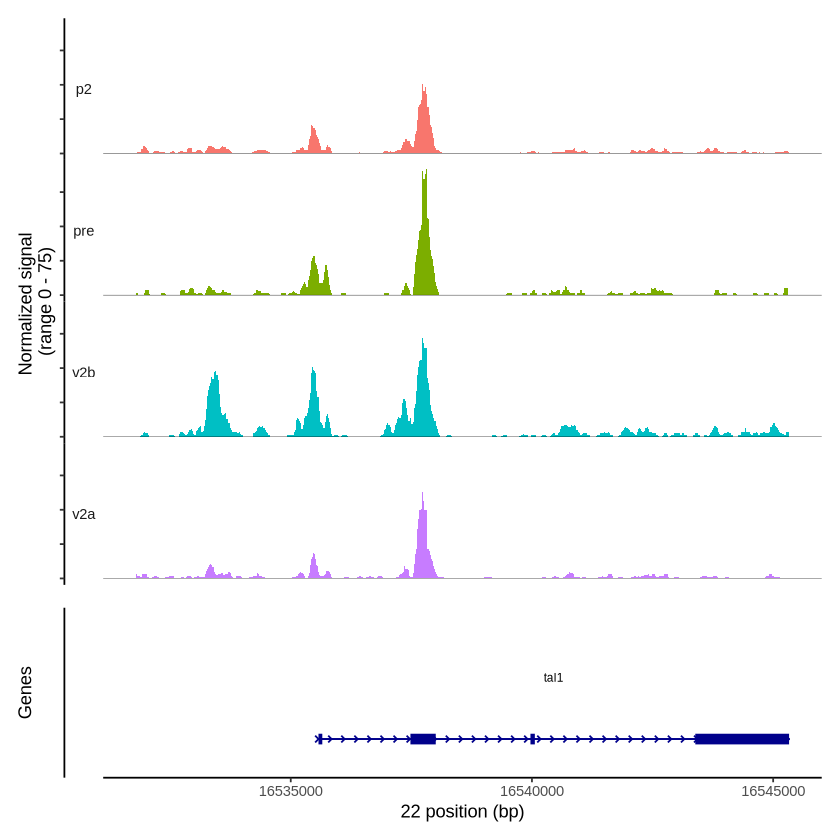

In [3]:
## replication of Figure 2G
CoveragePlot(v2av2b, region = 'tal1', extend.upstream = 3786, extend.downstream = 0, assay = 'ATAC', peaks = FALSE)

# environment

In [64]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/wangmei/anaconda3/envs/seurat5/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] hdf5r_1.3.11            AnnotationHub_3.10.0    BiocFileCache_2.10.1   
 [4] dbplyr_2.5.0            ensembldb_2.26.0        AnnotationFilter_1.26.0
 [7] GenomicFeatures_1.54.1  AnnotationDbi_1.64.1   

In [65]:
sessioninfo::session_info(to_file = "env_v2av2b_multiomic_tal1repressor.md")